# TOPOTEX Technical Report

> 面向组会 / leader 汇报 / 项目介绍的技术文档 notebook。
> 全部内容基于真实 TOPOTEX pipeline：只加载已有数据与 checkpoint，只做
> inference 与可视化；所有 shape、参数量由代码现场打印，绝无手写数字。

## Section 0 — TOPOTEX Overview

**核心思想：TOPOTEX 学习的是 Face Set Latent `Z_F`，而不是任何坐标空间上的纹理函数。**

传统做法把纹理建模为坐标的函数：

- ❌ `Texture(x, y, z)` — 依赖世界坐标，旋转/缩放就变
- ❌ `Texture(u, v)` — 依赖某一个具体 UV 参数化，换一次 unwrap 就变

TOPOTEX 把 mesh 的本质看作 **面的集合（Face Set）**，纹理是定义在面上的函数：

- ✅ `Texture(face_id, barycentric)`

XYZ 空间和 UV 空间都只是同一个 Face Set 的不同 **observation / query**：
XYZ 是几何观测（可被刚体变换改变），UV 是一次可替换的 2D 寻址方案。
`(face_id, barycentric)` 才是表面上稳定的身份坐标。

```mermaid
flowchart TD
    A["Reference Image"] --> C["Multi-view Generation<br/>(UniTEX Stage-1, offline)"]
    B["Textureless Mesh"] --> C
    B --> D["Surface Conditioner<br/>(FaceTokenizer + MV CrossAttn + Topology Transformer)"]
    C --> D
    D --> E["Face Set Latent  Z_F  [F, C]"]
    E --> F["UV Query Attention<br/>(any UV layout as query)"]
    F --> G["Texture Generator<br/>(rectified flow, Euler ODE)"]
    G --> H["UV Texture"]
```

**推论（本 notebook 逐节验证）**：同一个 `Z_F` 用不同 UV 参数化去 query，
生成的纹理回贴到 mesh 上应当外观一致（Section 7）；`Z_F` 对刚体变换、
均匀缩放不变（历史验证见 `experiments/experiment_log.md`，Section 8 摘录）。

## Setup — 环境、配置、checkpoint 自动加载

- 自动检测 device（cuda / cpu；渲染依赖 nvdiffrast，需要 CUDA）
- 自动加载 `configs/topotex_fm_baseline.yaml`
- checkpoint：`checkpoints/baseline`（最终基线）
- `RANDOM_SAMPLE=True` 时从该 checkpoint 的训练集中随机抽取一个样本贯穿全文

In [1]:
import json, random, sys, types
from pathlib import Path
p = Path.cwd()
PROJECT_ROOT = next(c for c in (p, *p.parents) if (c / "configs").exists())
sys.path.insert(0, str(PROJECT_ROOT))
DATASET_ROOT = PROJECT_ROOT / "output" / "topotex_dataset"

import numpy as np
import torch
import yaml
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC",
                                          "Noto Sans CJK JP", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
cfg = yaml.safe_load(open(PROJECT_ROOT / "configs" / "topotex_fm_baseline.yaml"))

RUN = PROJECT_ROOT / "checkpoints" / "baseline"
assert (RUN / "ckpt.pt").exists(), (
    "no baseline checkpoint - train one (python train.py ...) and place "
    "it under checkpoints/baseline (see README, Training section)")
ck = torch.load(RUN / "ckpt.pt", map_location=DEVICE, weights_only=False)

from train import build_models
from datasets.dataset import TopoTexDataset
from models.texture_generator import MaskedDiffusion

conditioner, dit = build_models(ck["config"], DEVICE)
conditioner.load_state_dict(ck["conditioner"])
dit.load_state_dict(ck["dit"])
conditioner.eval(); dit.eval()
diffusion = MaskedDiffusion(T=int(ck["config"]["T"]), device=DEVICE)

def nparam(m):
    return sum(q.numel() for q in m.parameters())

print("device            :", DEVICE)
print("checkpoint        :", RUN.name, "| global_step =", ck.get("global_step"))
print("train samples     :", len(ck["samples"]))
print("SurfaceConditioner: %.2fM params" % (nparam(conditioner) / 1e6))
print("  - FaceTokenizer      %.2fM" % (nparam(conditioner.tokenizer) / 1e6))
print("  - MultiViewEncoder   %.2fM" % (nparam(conditioner.image_encoder) / 1e6))
print("  - Face-MV CrossAttn  %.2fM" % (nparam(conditioner.cross) / 1e6))
print("  - TopologyTransformer%.2fM" % (nparam(conditioner.topo) / 1e6))
print("  - UVQueryAttention   %.2fM" % (nparam(conditioner.decoder) / 1e6))
print("MiniDiT           : %.2fM params" % (nparam(dit) / 1e6))
print("TOTAL             : %.2fM params" % ((nparam(conditioner) + nparam(dit)) / 1e6))

RANDOM_SAMPLE = True
sid = random.choice(ck["samples"]) if RANDOM_SAMPLE else ck["samples"][0]
ds = TopoTexDataset(DATASET_ROOT, [sid], device=DEVICE)
it = ds.items[0]
print("\nsample id         :", sid)

device            : cuda:0
checkpoint        : baseline | global_step = 123875
train samples     : 1982
SurfaceConditioner: 13.36M params
  - FaceTokenizer      0.14M
  - MultiViewEncoder   3.42M
  - Face-MV CrossAttn  1.58M
  - TopologyTransformer3.16M
  - UVQueryAttention   5.06M
MiniDiT           : 23.57M params
TOTAL             : 36.93M params

sample id         : 000d8f2e77714be8a75c5b9ad0b965e0


**可视化 helpers**（rebake 渲染 / 白模渲染 / face 颜色渲染 / PSNR，全部复用
`datasets/mesh_utils.py` 的光栅化与回贴函数）

In [2]:
from datasets.mesh_utils import (CANONICAL_VIEWS, camera_matrices,
                               dilate_texture, linear_to_srgb_u8,
                               rasterize_view, render_albedo_rebake)

V_np = it["mesh"]["vertices"].cpu().numpy().astype(np.float64)
F_np = it["mesh"]["faces"].cpu().numpy().astype(np.int64)

def gbuffer(vi, res=384):
    _, az, el = CANONICAL_VIEWS[vi]
    cam = camera_matrices(az, el, V_np.min(0), V_np.max(0))
    return rasterize_view(V_np, F_np, cam, res)

def render_white(vi, res=384):
    """textureless lambert render (geometry + topology only)."""
    gb = gbuffer(vi, res)
    tri = V_np[F_np]
    n = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
    n /= np.clip(np.linalg.norm(n, axis=1, keepdims=True), 1e-12, None)
    light = np.array([0.4, 0.6, 0.7]); light /= np.linalg.norm(light)
    lam = np.abs(n @ light)                    # winding-agnostic
    img = np.ones((res, res, 3))
    m = gb["mask"]
    img[m] = (0.25 + 0.75 * lam[gb["face_id"][m]])[:, None] *              np.array([0.86, 0.87, 0.90])
    return img

def render_face_colors(colors, vi, res=384):
    """per-face color [F,3] in [0,1] -> mesh render."""
    gb = gbuffer(vi, res)
    img = np.ones((res, res, 3))
    m = gb["mask"]
    img[m] = colors[gb["face_id"][m]]
    return img

def render_texture(q, tex_u8, vi, res=384):
    """rebake a UV texture through query q's UV layout, render view vi."""
    canon = types.SimpleNamespace(vertices=V_np, faces=F_np)
    uvr = types.SimpleNamespace(
        uv_vertices=q["uv_vertices"].astype(np.float64),
        uv_faces=q["uv_faces"], uv_face_to_mesh_face=np.arange(len(F_np)))
    gb = gbuffer(vi, res)
    v = q["valid_mask"].cpu().numpy()
    t = tex_u8.copy(); t[~v] = 0
    t = dilate_texture(t, v)
    return linear_to_srgb_u8(render_albedo_rebake(canon, uvr, t, gb)), gb["mask"]

def psnr(a, b, region=None):
    a = np.asarray(a, np.float64) / 255.0
    b = np.asarray(b, np.float64) / 255.0
    if region is not None:
        a, b = a[region], b[region]
    mse = float(((a - b) ** 2).mean())
    return round(10 * np.log10(1 / max(mse, 1e-12)), 2)

print("helpers ready (nvdiffrast renders require CUDA: %s)" %
      torch.cuda.is_available())

helpers ready (nvdiffrast renders require CUDA: True)


## Section 1 — Dataset Construction Pipeline

原始资产是 **带纹理的 GLB**（TexVerse，face < 4096 过滤）。
构建脚本：`datasets/build_dataset.py`（GLB 提取）→
`datasets/build_uv_queries.py`（UV query 集，本 notebook 使用的数据）。

| Step | 产物 | 说明 |
|---|---|---|
| 1 | `mesh.safetensors` | GLB 提取：`vertices [V,3]`, `faces [F,3]`, 原生 `uv_vertices/uv_faces` |
| 2 | `reference.png` | 参考图（单视角渲染） |
| 3 | 白模 mesh | 去掉外观，只保留 geometry / topology / face identity |
| 4 | `mv.safetensors` | UniTEX Stage-1 Multi-view Generation + Delight，六视角 `uint8 [6,3,256,256]`（离线冻结缓存） |
| 5 | `uv_queries/uv_*/uv_address.safetensors` | UV Address：每个 UV texel → `(face_id, barycentric)` |

### Step 1–3：GLB 提取 / Reference / 白模

Step 1  GLB extraction ->
  vertices: (4001, 3) torch.float32
  faces   : (3844, 3) torch.int64
Step 2  reference image: (512, 512, 3) (display as [3,H,W] tensor: (3, 512, 512) )


/tmp/ipykernel_260620/674789165.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538440907/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  tuple(torch.from_numpy(ref_img).permute(2, 0, 1).shape), ")")


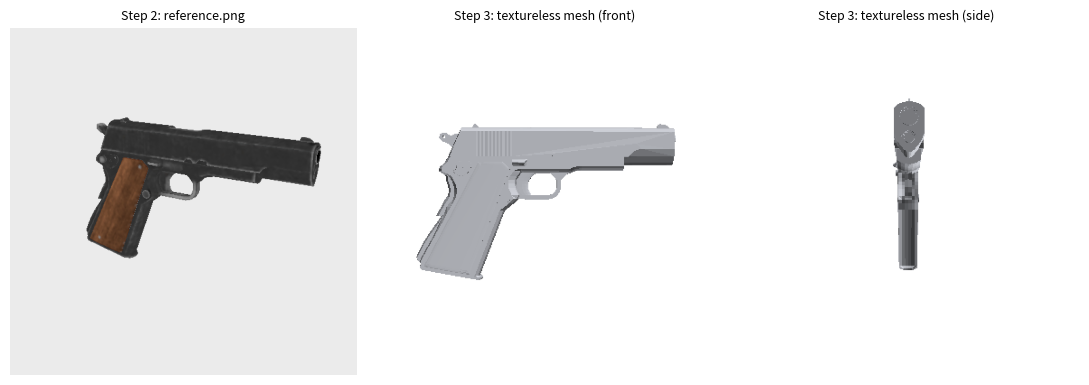

白模只保留 geometry / topology / face identity —— 外观信息全部来自 Step 4 的多视角图。


In [3]:
V_t, F_t = it["mesh"]["vertices"], it["mesh"]["faces"]
print("Step 1  GLB extraction ->")
print("  vertices:", tuple(V_t.shape), str(V_t.dtype))
print("  faces   :", tuple(F_t.shape), str(F_t.dtype))
ref_img = np.asarray(Image.open(DATASET_ROOT / "samples" / sid /
                                "reference.png").convert("RGB"))
print("Step 2  reference image:", ref_img.shape, "(display as [3,H,W] tensor:",
      tuple(torch.from_numpy(ref_img).permute(2, 0, 1).shape), ")")

white_front = render_white(0)
white_side = render_white(2)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(ref_img); axes[0].set_title("Step 2: reference.png", fontsize=9)
axes[1].imshow(white_front)
axes[1].set_title("Step 3: textureless mesh (front)", fontsize=9)
axes[2].imshow(white_side)
axes[2].set_title("Step 3: textureless mesh (side)", fontsize=9)
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()
print("白模只保留 geometry / topology / face identity —— 外观信息全部来自 Step 4 的多视角图。")

### Step 4：Multi-view Generation（UniTEX Stage-1 + Delight）

六个 canonical 视角（front / back / left / right / top / bottom），
离线生成并冻结为 `mv.safetensors`，训练时不再调用生成模型。

Step 4  multi-view tensor: (6, 3, 256, 256) torch.uint8


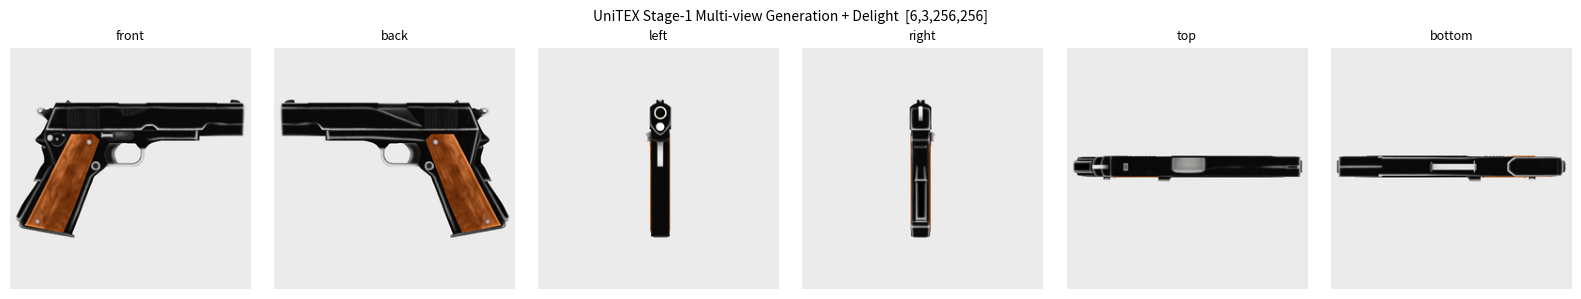

In [4]:
mv_u8 = it["mv_images"]                      # uint8 [6,3,256,256]
print("Step 4  multi-view tensor:", tuple(mv_u8.shape), str(mv_u8.dtype))
names = [v[0] for v in CANONICAL_VIEWS]
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(mv_u8[i].permute(1, 2, 0).cpu().numpy())
    ax.set_title(names[i], fontsize=9); ax.axis("off")
plt.suptitle("UniTEX Stage-1 Multi-view Generation + Delight  [6,3,256,256]",
             fontsize=10)
plt.tight_layout(); plt.show()

### Step 5：UV Address Construction（三个训练 query）

对每个 query 把 UV 布局光栅化到 256²，得到每个 texel 的表面地址：

```
UV pixel (x, y)  ->  (face_id, barycentric)
```

- `uv_000` **canonical**：原生 GLB 参数化
- `uv_001` **alternative family**：xatlas 重参数化（面序逐位保持，已断言）
- `uv_002` **partial surface query**：确定性连通面子集（25/50/75%），
  地址图由子集自身重光栅化产生，GT 在有效区重烘焙

GT 均经 `(face, bary) -> 原生 UV -> sRGB 双线性` 烘焙——三个 query 监督同一表面信号。

uv_address (per UV layout):
  face_id    : (256, 256) torch.int64 | -1 = background
  barycentric: (3, 256, 256) torch.float32
  valid_mask : (256, 256) torch.bool
  gt_texture : (3, 256, 256) torch.float32


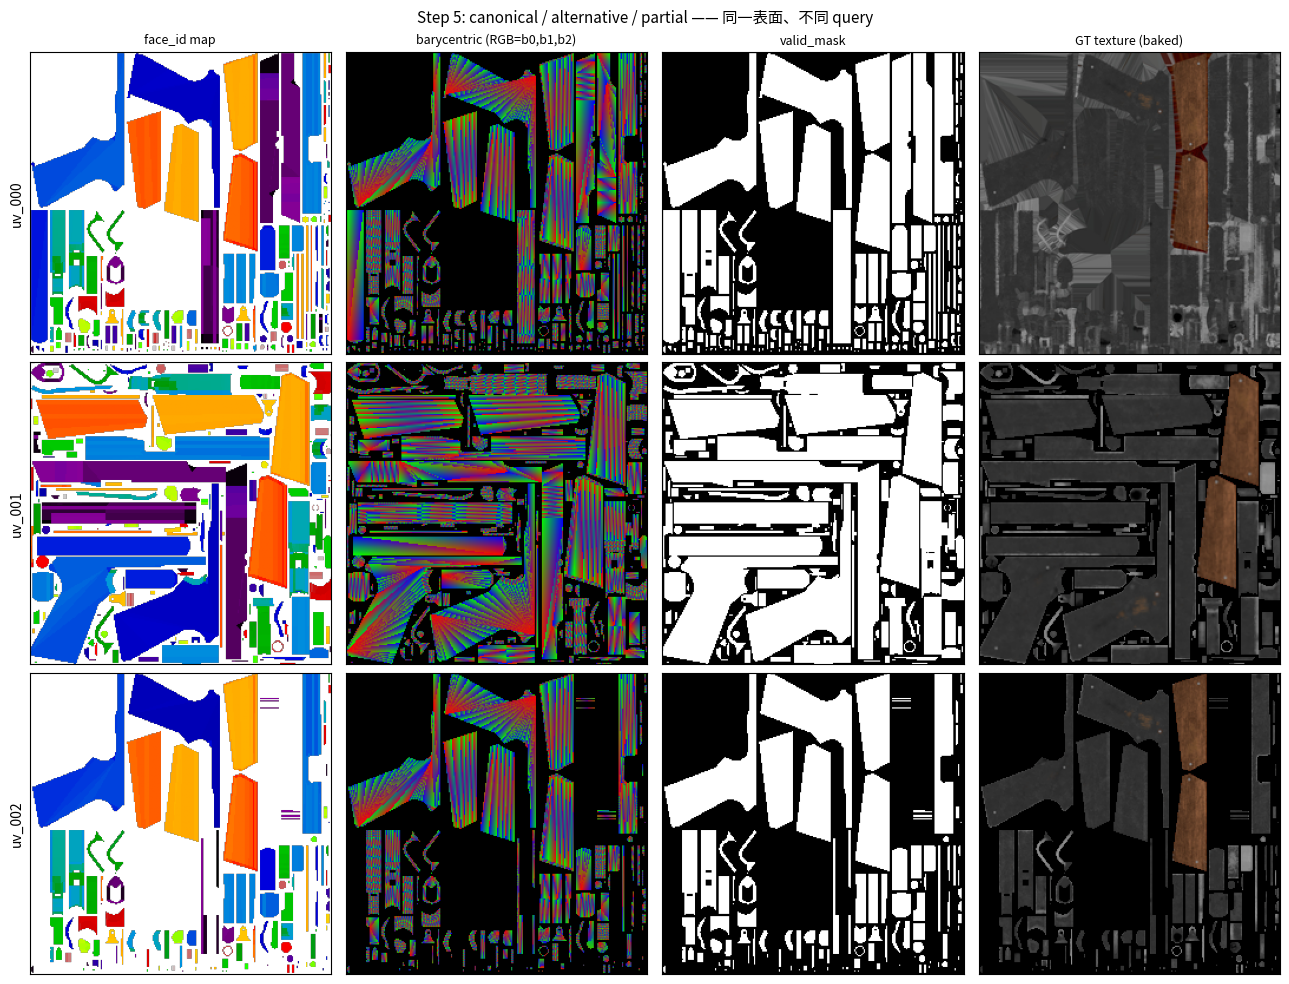

In [5]:
q0 = it["uv_queries"][0]
print("uv_address (per UV layout):")
print("  face_id    :", tuple(q0["face_id"].shape), str(q0["face_id"].dtype),
      "| -1 = background")
print("  barycentric:", tuple(q0["barycentric"].shape), str(q0["barycentric"].dtype))
print("  valid_mask :", tuple(q0["valid_mask"].shape), str(q0["valid_mask"].dtype))
print("  gt_texture :", tuple(q0["gt_texture"].shape), str(q0["gt_texture"].dtype))

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for r, q in enumerate(it["uv_queries"]):
    fid = q["face_id"].cpu().numpy().astype(np.float64)
    fid[fid < 0] = np.nan
    axes[r][0].imshow(fid, cmap="nipy_spectral")
    axes[r][0].set_ylabel(q["name"], fontsize=10)
    axes[r][0].set_title("face_id map" if r == 0 else "", fontsize=9)
    bary = q["barycentric"].permute(1, 2, 0).cpu().numpy().astype(np.float64)
    bary[~q["valid_mask"].cpu().numpy()] = 0
    axes[r][1].imshow(bary)
    axes[r][1].set_title("barycentric (RGB=b0,b1,b2)" if r == 0 else "", fontsize=9)
    axes[r][2].imshow(q["valid_mask"].cpu().numpy(), cmap="gray")
    axes[r][2].set_title("valid_mask" if r == 0 else "", fontsize=9)
    axes[r][3].imshow(q["gt_texture"].permute(1, 2, 0).cpu().numpy())
    axes[r][3].set_title("GT texture (baked)" if r == 0 else "", fontsize=9)
for a in axes.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("Step 5: canonical / alternative / partial —— 同一表面、不同 query",
             fontsize=11)
plt.tight_layout(); plt.show()

## Section 2 — Interactive Dataset Inspector

`inspect_sample(sample_id)`：任意样本的一页式检查。`RANDOM_SAMPLE=True`
时下方展示的是随机抽中的样本。

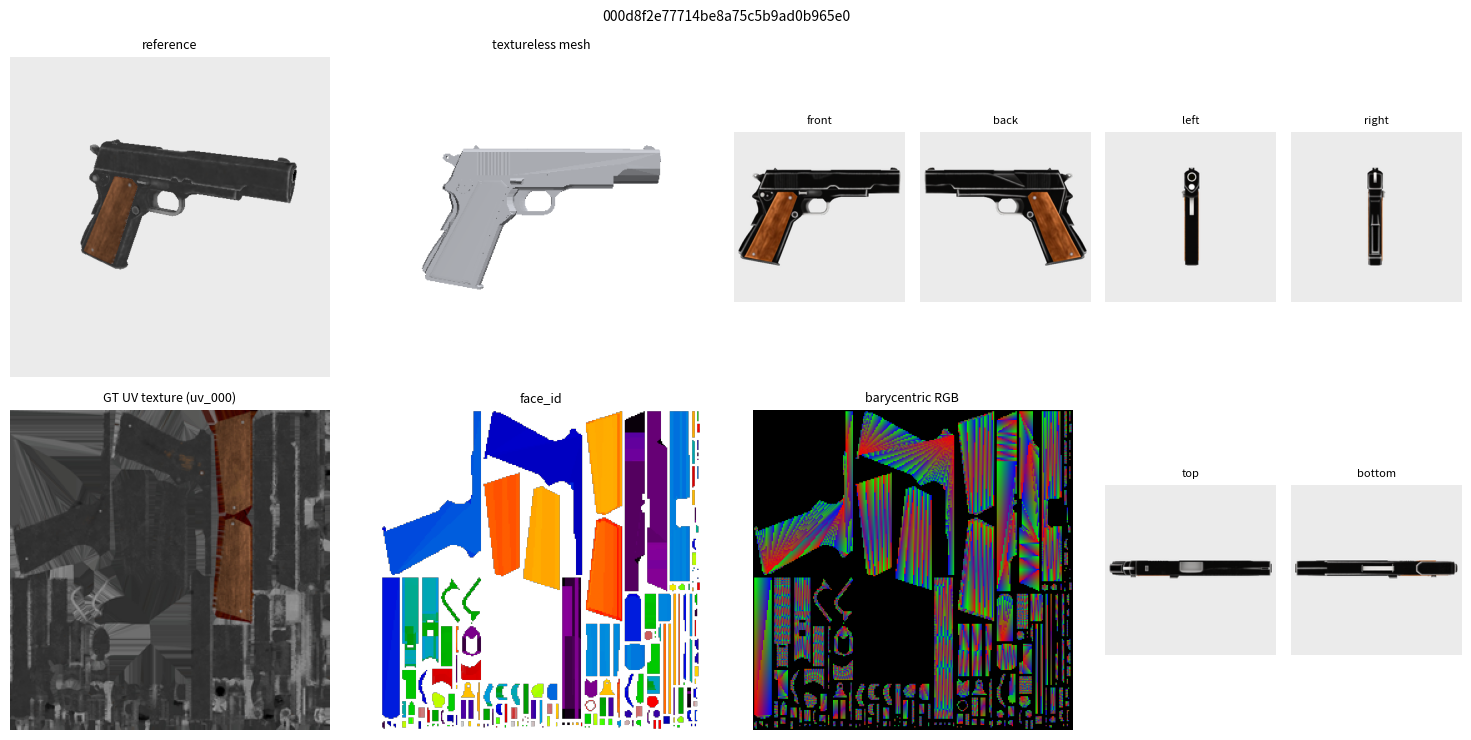

sample_id : 000d8f2e77714be8a75c5b9ad0b965e0
vertices  : (4001, 3) | faces: (3844, 3)
texture   : (3, 256, 256) | uv_queries: ['uv_000', 'uv_001', 'uv_002'] | held-out: ['uv_test']
num_faces : 3844 | build_seconds: 0.05


In [6]:
def inspect_sample(sample_id):
    d = TopoTexDataset(DATASET_ROOT, [sample_id], device=DEVICE).items[0]
    meta = json.loads((DATASET_ROOT / "samples" / sample_id /
                       "meta.json").read_text())
    Vl = d["mesh"]["vertices"].cpu().numpy().astype(np.float64)
    Fl = d["mesh"]["faces"].cpu().numpy().astype(np.int64)
    _, az, el = CANONICAL_VIEWS[0]
    gb = rasterize_view(Vl, Fl, camera_matrices(az, el, Vl.min(0), Vl.max(0)), 384)
    tri = Vl[Fl]
    n = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
    n /= np.clip(np.linalg.norm(n, axis=1, keepdims=True), 1e-12, None)
    lam = np.abs(n @ np.array([0.4, 0.6, 0.7]) / np.linalg.norm([0.4, 0.6, 0.7]))
    white = np.ones((384, 384, 3))
    white[gb["mask"]] = (0.25 + 0.75 * lam[gb["face_id"][gb["mask"]]])[:, None]         * np.array([0.86, 0.87, 0.90])

    fig = plt.figure(figsize=(15, 7.5))
    gs = fig.add_gridspec(2, 8)
    ax = fig.add_subplot(gs[0, :2])
    ax.imshow(np.asarray(Image.open(DATASET_ROOT / "samples" / sample_id /
                                    "reference.png").convert("RGB")))
    ax.set_title("reference", fontsize=9); ax.axis("off")
    ax = fig.add_subplot(gs[0, 2:4])
    ax.imshow(white); ax.set_title("textureless mesh", fontsize=9); ax.axis("off")
    for i in range(4):
        ax = fig.add_subplot(gs[0, 4 + i])
        ax.imshow(d["mv_images"][i].permute(1, 2, 0).cpu().numpy())
        ax.set_title(CANONICAL_VIEWS[i][0], fontsize=8); ax.axis("off")
    q = d["uv_queries"][0]
    ax = fig.add_subplot(gs[1, :2])
    ax.imshow(q["gt_texture"].permute(1, 2, 0).cpu().numpy())
    ax.set_title("GT UV texture (uv_000)", fontsize=9); ax.axis("off")
    fid = q["face_id"].cpu().numpy().astype(np.float64); fid[fid < 0] = np.nan
    ax = fig.add_subplot(gs[1, 2:4])
    ax.imshow(fid, cmap="nipy_spectral")
    ax.set_title("face_id", fontsize=9); ax.axis("off")
    bary = q["barycentric"].permute(1, 2, 0).cpu().numpy().astype(np.float64)
    bary[~q["valid_mask"].cpu().numpy()] = 0
    ax = fig.add_subplot(gs[1, 4:6])
    ax.imshow(bary); ax.set_title("barycentric RGB", fontsize=9); ax.axis("off")
    for i in range(2):
        ax = fig.add_subplot(gs[1, 6 + i])
        ax.imshow(d["mv_images"][4 + i].permute(1, 2, 0).cpu().numpy())
        ax.set_title(CANONICAL_VIEWS[4 + i][0], fontsize=8); ax.axis("off")
    plt.suptitle(sample_id, fontsize=10); plt.tight_layout(); plt.show()
    print("sample_id :", sample_id)
    print("vertices  :", tuple(d["mesh"]["vertices"].shape),
          "| faces:", tuple(d["mesh"]["faces"].shape))
    print("texture   :", tuple(q["gt_texture"].shape),
          "| uv_queries:", [x["name"] for x in d["uv_queries"]],
          "| held-out:", [x["name"] for x in d["test_uv_queries"]])
    print("num_faces :", meta["num_faces"], "| build_seconds:",
          meta.get("build_seconds"))

inspect_sample(sid)

## Section 3 — Surface Conditioner Architecture

`models/surface_conditioner/conditioner.py::encode_faces` 的完整通路
的完整通路。**输入没有 XYZ 坐标、没有 UV、没有 face index**：

### 3.1 Face Tokenizer（`face_tokenizer.py`）
- 输入：mesh（vertices, faces）→ 每面 **纯内在几何**：
  - 3 条边长 / mesh 尺度（`sqrt(总面积)`）
  - 3 条边长 / 周长
  - 3 个内角 / π（面内排序，与顶点顺序无关）
  - log 归一化面积 + 边界面比例
- 拼接 Topology PE（random-walk，k=16，纯图结构）→ MLP → **Face Tokens `[F, C]`**
- 全部是比值/角度 → 对刚体变换与均匀缩放按构造不变（Section 8 验证）

### 3.2 Multi-view Image Encoder（`image_encoder.py`）
- 输入 `[6, 3, 256, 256]`，从零训练（无 CLIP/DINO）
- Conv patch embedding（patch 16）+ 2D pos embedding + **learnable view embedding**
- 全视角 token 联合 self-attention → **Image Tokens `[N_img, C]`**

### 3.3 Face–Image Cross Attention（`face_image_attention.py`）
- `Q =` Face Tokens，`K,V =` Image Tokens → 外观注入 → Appearance Face Tokens `[F, C]`

### 3.4 Topology Transformer（`topology_transformer.py`）
- 稀疏图注意力：只沿 **shared-edge 面邻接**（无 XYZ/欧氏 KNN）
- 学习的 relation bias：共享边长 / 二面角 / 边界 flag
- 输出 = **Canonical Face Set Latent `Z_F [F, C]`**

下面逐步执行真实前向，打印每一级 shape，并与 `encode_faces` 输出比对：

In [7]:
mv = it["mv_images"].float()[None] / 255
graph = it["graph"]
Fn = len(it["mesh"]["faces"])
with torch.no_grad():
    pe = conditioner.topo_pe(graph, Fn)
    from models.surface_conditioner.face_tokenizer import face_intrinsic_features
    intrinsic = face_intrinsic_features(it["mesh"]["vertices"],
                                        it["mesh"]["faces"],
                                        graph["global_scale"])
    x_tok = conditioner.tokenizer(it["mesh"]["vertices"],
                                  it["mesh"]["faces"], graph, pe)
    img_tokens = conditioner.image_encoder(mv)
    x_cross = conditioner.cross(x_tok.unsqueeze(0), img_tokens).squeeze(0)
    Z_F = conditioner.topo(x_cross, graph)
    Z_ref, _ = conditioner.encode_faces(it["mesh"], mv, graph)

print("mesh vertices          :", tuple(it["mesh"]["vertices"].shape))
print("mesh faces             :", tuple(it["mesh"]["faces"].shape))
print("intrinsic features     :", tuple(intrinsic.shape),
      "(edge/scale x3, edge/perimeter x3, angle/pi x3, log-area)")
print("topology PE            :", tuple(pe.shape))
print("Face Tokens            :", tuple(x_tok.shape))
print("MV input               :", tuple(mv.shape))
print("Image Tokens           :", tuple(img_tokens.shape),
      "= 6 views x %d patch tokens" % conditioner.image_encoder.tokens_per_view)
print("after Face-MV CrossAttn:", tuple(x_cross.shape))
print("Z_F (Face Set Latent)  :", tuple(Z_F.shape))
diff = float((Z_F - Z_ref).abs().max())
print("matches encode_faces   : max|diff| = %.2e" % diff,
      "(float atomics tolerance)")
print("graph edges            :", tuple(graph["edges"].shape),
      "| rel:", tuple(graph["rel"].shape),
      "(shared edge len, dihedral, boundary)")

mesh vertices          : (4001, 3)
mesh faces             : (3844, 3)
intrinsic features     : (3844, 10) (edge/scale x3, edge/perimeter x3, angle/pi x3, log-area)
topology PE            : (3844, 16)
Face Tokens            : (3844, 256)
MV input               : (1, 6, 3, 256, 256)
Image Tokens           : (1, 1536, 256) = 6 views x 256 patch tokens
after Face-MV CrossAttn: (3844, 256)
Z_F (Face Set Latent)  : (3844, 256)
matches encode_faces   : max|diff| = 2.10e-05 (float atomics tolerance)
graph edges            : (8102, 2) | rel: (8102, 3) (shared edge len, dihedral, boundary)


/root/youjiaZhang/TopoTex/models/surface_conditioner/topology_transformer.py:16: UserWarning: index_reduce() is in beta and the API may change at any time. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538440907/work/aten/src/ATen/native/cuda/Indexing.cu:1185.)
  m = m.index_reduce(0, index, scores, "amax", include_self=True)


## Section 4 — Face Token Visualization（重点）

**每一个 triangle 对应一个 latent token。** 把 `Z_F [F, C]` 做 PCA 投到 3 维
作为 face 颜色，直接按 `face_id` 渲染回 mesh 三角形 —— 可以直观看到 latent
在表面上的组织方式（语义部件/朝向/材质区域自发聚类）。

`visualize_face_tokens(sample_id)` 对任意样本可复现此图。

Z_F: (3844, 256) -> PCA face colors: (3844, 3) | explained variance: [0.249 0.095 0.08 ]


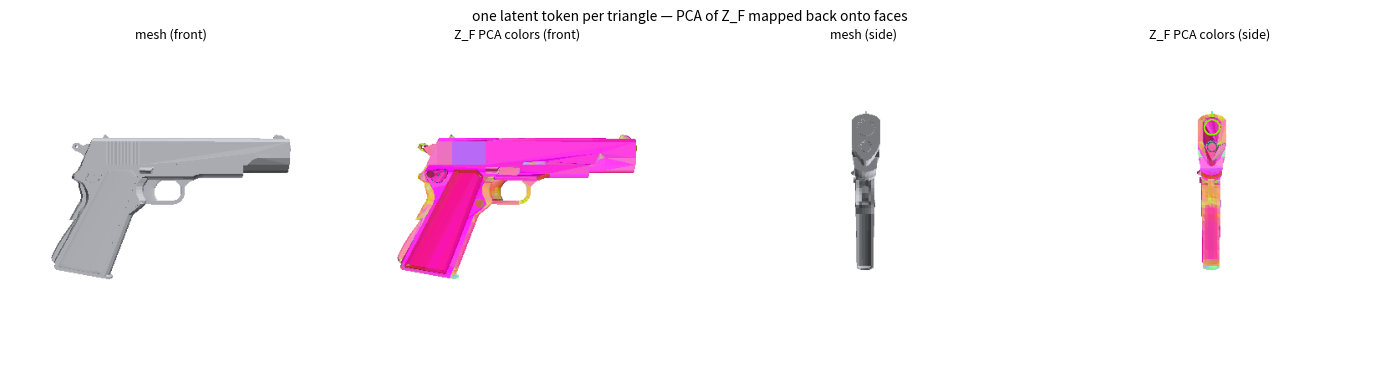

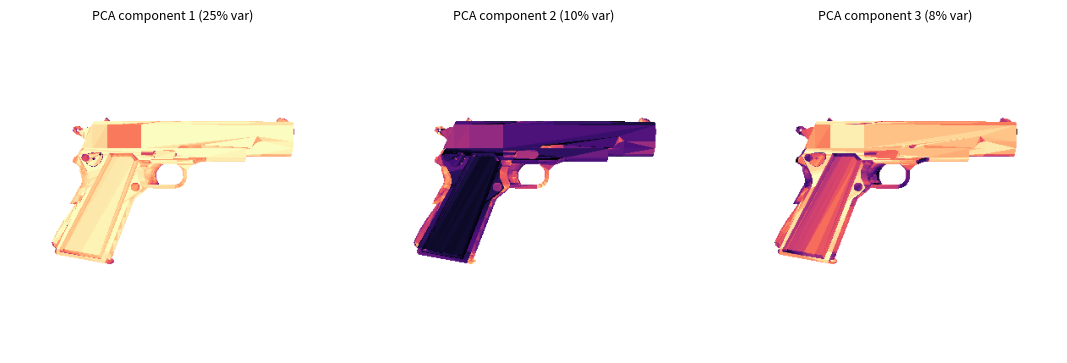

visualize_face_tokens on a second sample: 011499017e4d


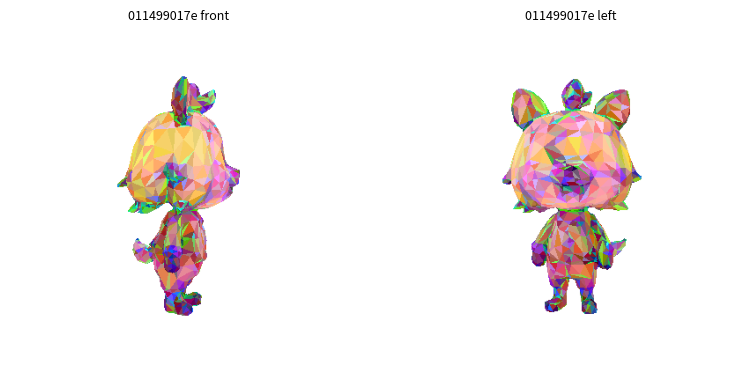

In [8]:
def face_pca(Z, k=3):
    Zc = Z - Z.mean(0)
    U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    pc = Zc @ Vt[:k].T
    lo = np.percentile(pc, 2, axis=0)
    hi = np.percentile(pc, 98, axis=0)
    return np.clip((pc - lo) / (hi - lo + 1e-9), 0, 1),         (S[:k] ** 2 / (S ** 2).sum())

Z_np = Z_F.cpu().numpy()
pca_colors, evr = face_pca(Z_np)
print("Z_F:", Z_np.shape, "-> PCA face colors:", pca_colors.shape,
      "| explained variance: %s" % np.round(evr, 3))

pca_render_front = render_face_colors(pca_colors, 0)
pca_render_side = render_face_colors(pca_colors, 2)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
axes[0].imshow(white_front); axes[0].set_title("mesh (front)", fontsize=9)
axes[1].imshow(pca_render_front)
axes[1].set_title("Z_F PCA colors (front)", fontsize=9)
axes[2].imshow(render_white(2)); axes[2].set_title("mesh (side)", fontsize=9)
axes[3].imshow(pca_render_side)
axes[3].set_title("Z_F PCA colors (side)", fontsize=9)
for a in axes: a.axis("off")
plt.suptitle("one latent token per triangle — PCA of Z_F mapped back onto faces",
             fontsize=10)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for c in range(3):
    scal = np.clip(pca_colors[:, c], 0, 1)
    cm = plt.get_cmap("magma")(scal)[:, :3]
    axes[c].imshow(render_face_colors(cm, 0))
    axes[c].set_title("PCA component %d (%.0f%% var)" %
                      (c + 1, 100 * evr[c]), fontsize=9)
    axes[c].axis("off")
plt.tight_layout(); plt.show()

def visualize_face_tokens(sample_id, views=(0, 2)):
    d = TopoTexDataset(DATASET_ROOT, [sample_id], device=DEVICE).items[0]
    with torch.no_grad():
        z, _ = conditioner.encode_faces(
            d["mesh"], d["mv_images"].float()[None] / 255, d["graph"])
    colors, _ = face_pca(z.cpu().numpy())
    Vl = d["mesh"]["vertices"].cpu().numpy().astype(np.float64)
    Fl = d["mesh"]["faces"].cpu().numpy().astype(np.int64)
    fig, axes = plt.subplots(1, len(views), figsize=(4 * len(views), 3.8))
    for a, vi in zip(np.atleast_1d(axes), views):
        _, az, el = CANONICAL_VIEWS[vi]
        gb = rasterize_view(Vl, Fl,
                            camera_matrices(az, el, Vl.min(0), Vl.max(0)), 384)
        img = np.ones((384, 384, 3))
        img[gb["mask"]] = colors[gb["face_id"][gb["mask"]]]
        a.imshow(img); a.axis("off")
        a.set_title(sample_id[:10] + " " + CANONICAL_VIEWS[vi][0], fontsize=9)
    plt.tight_layout(); plt.show()

sid2 = random.choice([s for s in ck["samples"] if s != sid])
print("visualize_face_tokens on a second sample:", sid2[:12])
visualize_face_tokens(sid2)

## Section 5 — UV Query Pipeline

UV 布局如何读取 `Z_F`（`uv_query_attention.py`，全局注意力，无 routing、无 mask）：

```
per-texel:  [ face_token(face_id) ‖ bary_encoding(barycentric) ] --Linear--> texel feature
patchify:   256x256, patch=8  ->  32x32 = 1024 query tokens (+ learned atlas pos embed)
N x CrossBlock:   Q = UV query tokens,   K,V = Z_F  (全部 face tokens)
unpatchify: uv_condition [64, 256, 256]（背景清零）
```

UV 布局只决定 *每个 patch 引用哪些面*；表面内容 **只能** 通过对 `Z_F`
的注意力流入。下方用 forward hooks 打印真实各级 shape，并将同一个 `Z_F`
在三种 UV 布局下的 `uv_condition` 做 PCA 可视化：

decoder trace (uv_000 forward):
  texel Linear       in (33068, 283)       out (33068, 32)
  patch embed Linear in (1024, 2048)       out (1024, 256)
  CrossBlock 0       in (1, 1024, 256)     out (1, 1024, 256)
  CrossBlock 1       in (1, 1024, 256)     out (1, 1024, 256)
  CrossBlock 2       in (1, 1024, 256)     out (1, 1024, 256)
  CrossBlock 3       in (1, 1024, 256)     out (1, 1024, 256)
  cond head Linear   in (1024, 256)        out (1024, 4096)
query tokens: 1024 (grid 32x32, patch 8)
uv_condition: (64, 256, 256)


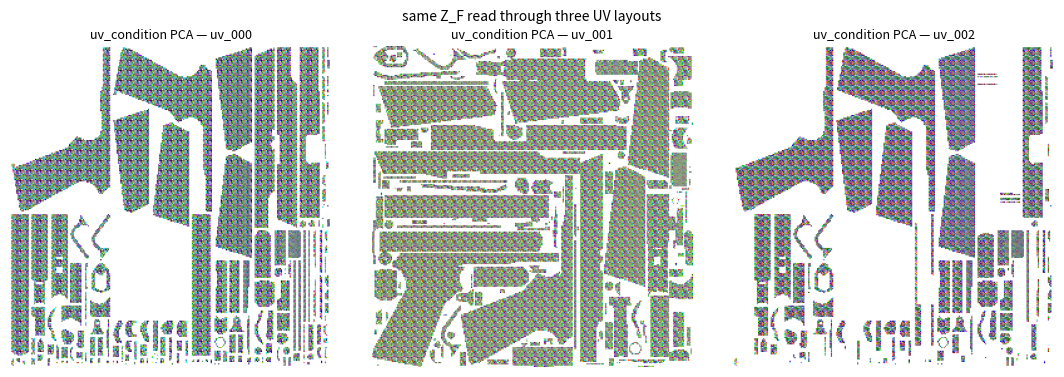

In [9]:
dec = conditioner.decoder
shape_log = []
def _mk(name):
    def h(_m, inp, out):
        o = out[0] if isinstance(out, tuple) else out
        shape_log.append((name, tuple(inp[0].shape), tuple(o.shape)))
    return h
hooks = [dec.texel.register_forward_hook(_mk("texel Linear")),
         dec.embed.register_forward_hook(_mk("patch embed Linear"))]
hooks += [b.register_forward_hook(_mk("CrossBlock %d" % i))
          for i, b in enumerate(dec.blocks)]
hooks.append(dec.head.register_forward_hook(_mk("cond head Linear")))

conds = {}
with torch.no_grad():
    for q in it["uv_queries"]:
        cond_map, _ = dec(Z_F, q["face_id"],
                          q["barycentric"].permute(1, 2, 0))
        conds[q["name"]] = cond_map
for h in hooks: h.remove()

print("decoder trace (uv_000 forward):")
seen = set()
for name, si, so in shape_log:
    if name in seen: continue
    seen.add(name)
    print("  %-18s in %-18s out %s" % (name, si, so))
print("query tokens:", dec.grid * dec.grid,
      "(grid %dx%d, patch %d)" % (dec.grid, dec.grid, dec.patch))
print("uv_condition:", tuple(next(iter(conds.values())).shape))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (nm, cm) in zip(axes, conds.items()):
    c = cm.cpu().numpy().reshape(cm.shape[0], -1).T          # [HW, 64]
    colors, _ = face_pca(c)
    img = colors.reshape(cm.shape[1], cm.shape[2], 3)
    vq = [x for x in it["uv_queries"] if x["name"] == nm][0]
    img[~vq["valid_mask"].cpu().numpy()] = 1
    ax.imshow(img); ax.axis("off")
    ax.set_title("uv_condition PCA — " + nm, fontsize=9)
plt.suptitle("same Z_F read through three UV layouts", fontsize=10)
plt.tight_layout(); plt.show()

## Section 6 — Texture Generation（rectified flow 主线）

`models/texture_generator/flow_matching.py`：rectified flow ——
`x_tau = (1-tau)·x0 + tau·eps`，网络（`dit.py` 的 patchified transformer，
AdaLN-Zero，冻结结构复用为速度网络）输出速度场 `v = eps - x0`，
采样 = tau 1→0 的 Euler 积分（50 步）。无效区域全程固定为 0。
masked-diffusion schedule 保留为归档参考（可加载旧 checkpoint）。
参数量与结构全部从 model / config 现场读取。下面展示轨迹中间的瞬时
`x0` 估计（tau=1 → 0）以及最终纹理 vs GT：

MiniDiT: 23.57M params
  depth      : 8
  hidden dim : 384
  heads      : 6 (config)
  patch size : 8 -> token grid 32x32 = 1024
  cond input : 64 channels
  generator  : fm | T=1000


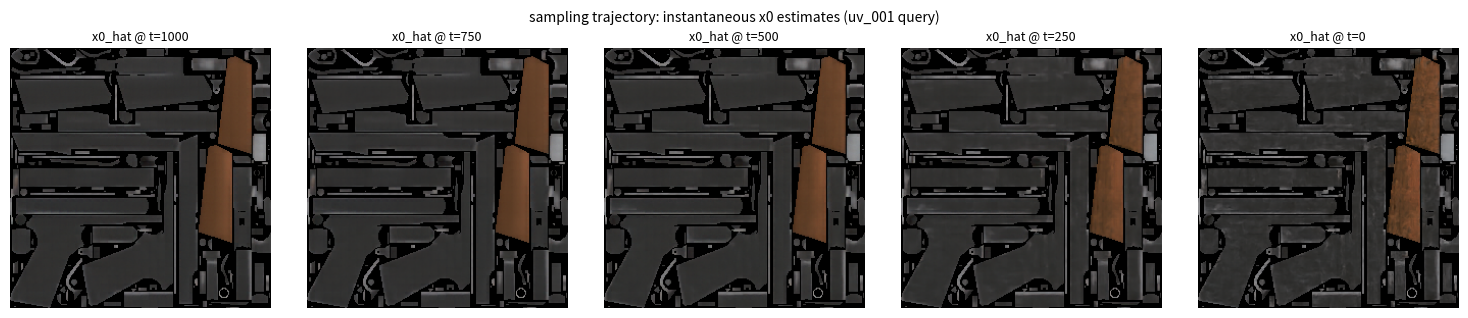

final texture vs GT — UV PSNR (valid region): 27.80 dB


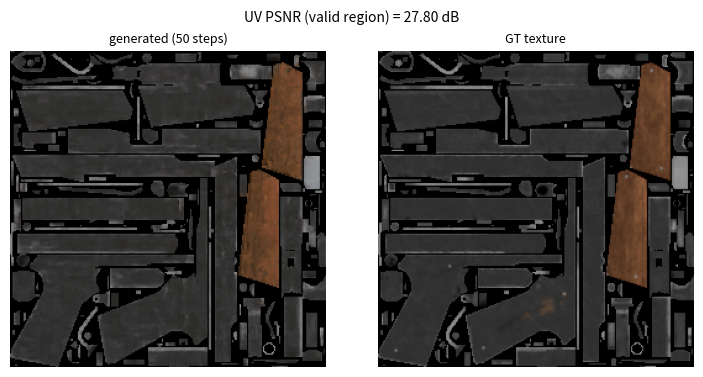

In [10]:
print("MiniDiT: %.2fM params" % (nparam(dit) / 1e6))
print("  depth      :", len(dit.blocks))
print("  hidden dim :", dit.embed_x.out_channels)
print("  heads      :", int(cfg["dit_heads"]), "(config)")
print("  patch size :", dit.patch, "-> token grid %dx%d = %d" %
      (dit.grid, dit.grid, dit.grid * dit.grid))
print("  cond input :", dit.embed_c.in_channels, "channels")
print("  generator  :", ck["config"].get("generator", "diffusion"),
      "| T=%d" % diffusion.T)

q_gen = it["uv_queries"][1]
cond_gen = conds[q_gen["name"]][None]
mask_gen = q_gen["valid_mask"].float()[None, None]

def trajectory_with_intermediates(cond, mask, steps=50, seed=20260727,
                                  capture=(1000, 750, 500, 250)):
    """Generator-agnostic sampling trajectory capturing instantaneous x0
    estimates. Rectified flow: x0_hat = x - tau * v. Diffusion (previous
    reference): standard DDIM x0_hat."""
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    B, _, H, W = mask.shape
    x = torch.randn(B, 3, H, W, device=mask.device, generator=g) * mask
    caps = {}
    is_fm = ck["config"].get("generator") == "fm"
    if is_fm:
        taus = torch.linspace(1.0, 0.0, steps + 1, device=mask.device)
        for i in range(steps):
            t_int = (taus[i] * diffusion.T).round().clamp(min=1).long()
            with torch.no_grad():
                v = dit(x, cond, mask, t_int.expand(B))
            x0_hat = (x - taus[i] * v).clamp(-1, 1)
            for ct in capture:
                if ct not in caps and int(t_int) <= ct:
                    caps[ct] = x0_hat[0].clone()
            x = (x - (taus[i] - taus[i + 1]) * v) * mask
        caps[0] = x.clamp(-1, 1)[0].clone()
        return caps
    ts = torch.linspace(diffusion.T, 1, steps,
                        device=mask.device).round().long()
    ab = diffusion.alphas_cumprod.float()
    for i in range(steps):
        t = ts[i]
        ab_t = ab[t - 1]
        ab_prev = ab[ts[i + 1] - 1] if i + 1 < steps else torch.tensor(
            1.0, device=mask.device)
        with torch.no_grad():
            eps = dit(x, cond, mask, t.expand(B))
        x0_hat = ((x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()).clamp(-1, 1)
        eps = (x - ab_t.sqrt() * x0_hat) / (1 - ab_t).sqrt().clamp(min=1e-8)
        for ct in capture:
            if ct not in caps and int(t) <= ct:
                caps[ct] = x0_hat[0].clone()
        x = (ab_prev.sqrt() * x0_hat + (1 - ab_prev).sqrt() * eps) * mask
    caps[0] = x0_hat[0].clone()
    return caps

caps = trajectory_with_intermediates(cond_gen, mask_gen)

def to_img(x, valid):
    img = ((x.clamp(-1, 1) + 1) / 2 * 255).round().byte()
    img = img.permute(1, 2, 0).cpu().numpy().copy()
    img[~valid.cpu().numpy()] = 0
    return img

fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, t in zip(axes, (1000, 750, 500, 250, 0)):
    ax.imshow(to_img(caps[t], q_gen["valid_mask"]))
    ax.set_title("x0_hat @ t=%d" % t, fontsize=9); ax.axis("off")
plt.suptitle("sampling trajectory: instantaneous x0 estimates (uv_001 query)", fontsize=10)
plt.tight_layout(); plt.show()

gen_tex = to_img(caps[0], q_gen["valid_mask"])
gt_tex = (q_gen["gt_texture"].permute(1, 2, 0).cpu().numpy() * 255
          ).astype(np.uint8)
uv_psnr_val = psnr(gt_tex, gen_tex, q_gen["valid_mask"].cpu().numpy())
print("final texture vs GT — UV PSNR (valid region): %.2f dB" % uv_psnr_val)
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))
axes[0].imshow(gen_tex); axes[0].set_title("generated (50 steps)", fontsize=9)
axes[1].imshow(gt_tex); axes[1].set_title("GT texture", fontsize=9)
for a in axes: a.axis("off")
plt.suptitle("UV PSNR (valid region) = %.2f dB" % uv_psnr_val, fontsize=10)
plt.tight_layout(); plt.show()

## Section 7 — Multi-UV Consistency Demo（核心）

**同一个 mesh、同一个 `Z_F`，三个 query（canonical / alternative / partial）
各生成一张纹理，全部 rebake 回 mesh 渲染。** 两个全查询的 render 应共享同一
外观：`R(M,U0,T0)` vs `R(M,U1,T1)` 的 pairwise PSNR（6 视角），并与各自对 GT
的 render fidelity 对比——**consistency ≥ GT fidelity 即为解耦签名**。
partial query 则验证：只查询表面一部分时，该区域可独立生成、区域外严格为零。

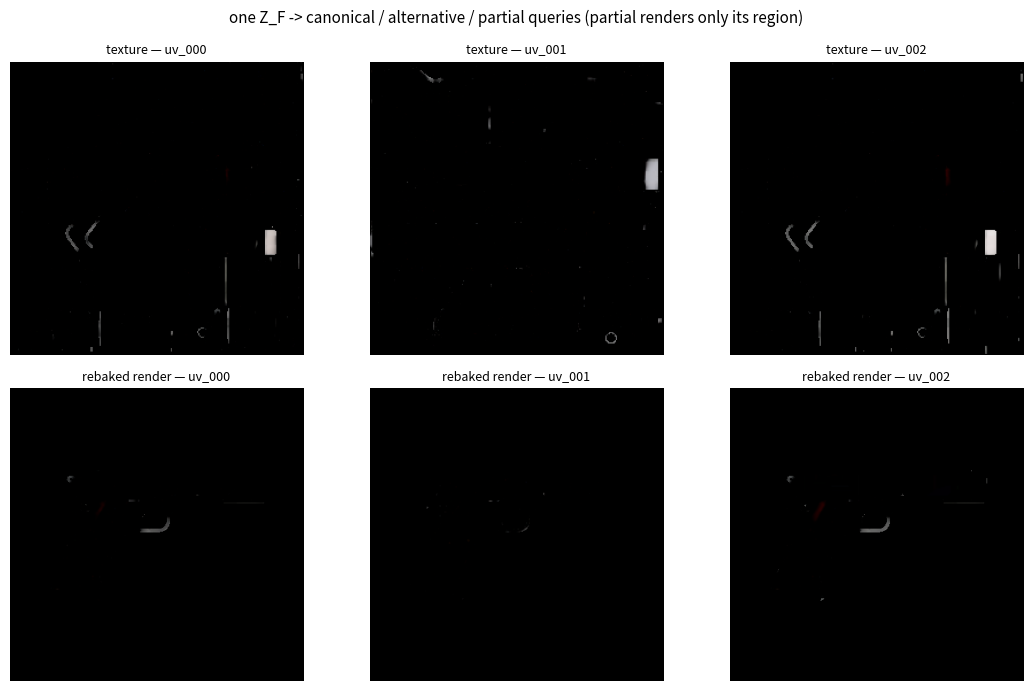

render consistency R(M,U0,T0) vs R(M,U1,T1), 6 views: 28.19 dB
partial query (uv_002) region PSNR: 12.68 dB | outside-region zero: True


mean GT-render fidelity     : 12.39 dB
decoupling signature        : consistency >= GT fidelity (28.19 vs 12.39)
解读：三布局预测间的吻合度与各自对 GT 的还原度相当或更高 —— 它们共享同一个来自 Z_F 的表面信号，UV 只是 query。


In [11]:
gens = {}
with torch.no_grad():
    for q in it["uv_queries"]:
        g = torch.Generator(device=DEVICE).manual_seed(20260727)
        x = diffusion.ddim_sample(dit, conds[q["name"]][None],
                                  q["valid_mask"].float()[None, None],
                                  steps=50, generator=g)[0]
        gens[q["name"]] = to_img(x, q["valid_mask"])

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
rebakes = {}
for c, q in enumerate(it["uv_queries"]):
    nm = q["name"]
    axes[0][c].imshow(gens[nm])
    axes[0][c].set_title("texture — " + nm, fontsize=9)
    img, _ = render_texture(q, gens[nm], 0)
    rebakes[nm] = img
    axes[1][c].imshow(img)
    axes[1][c].set_title("rebaked render — " + nm, fontsize=9)
for a in axes.ravel(): a.axis("off")
plt.suptitle("one Z_F -> canonical / alternative / partial queries "
             "(partial renders only its region)", fontsize=11)
plt.tight_layout(); plt.show()

qa = [q for q in it["uv_queries"] if q["name"] == "uv_000"][0]
qb = [q for q in it["uv_queries"] if q["name"] == "uv_001"][0]
vals = []
for vi in range(6):
    ia, ma = render_texture(qa, gens["uv_000"], vi)
    ib, mb = render_texture(qb, gens["uv_001"], vi)
    m = ma & mb
    if m.sum() >= 100:
        vals.append(psnr(ia, ib, m))
cons_mean = float(np.mean(vals))
print("render consistency R(M,U0,T0) vs R(M,U1,T1), 6 views: %.2f dB"
      % cons_mean)

# partial surface query: UV-space region PSNR (its own valid region)
qp = [q for q in it["uv_queries"] if q["name"] == "uv_002"][0]
vp = qp["valid_mask"].cpu().numpy()
gtp = (qp["gt_texture"].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
print("partial query (uv_002) region PSNR: %.2f dB | outside-region zero: %s"
      % (psnr(gtp, gens["uv_002"], vp),
         bool((gens["uv_002"][~vp] == 0).all())))

# decoupling signature on the two FULL queries: do the two predictions agree
# with each other at least as well as each matches GT?
gt_vals = []
for q, nm in ((qa, "uv_000"), (qb, "uv_001")):
    gtq = (q["gt_texture"].permute(1, 2, 0).cpu().numpy() * 255
           ).astype(np.uint8)
    vals = []
    for vi in range(6):
        ia, ma = render_texture(q, gens[nm], vi)
        ib, mb = render_texture(q, gtq, vi)
        m = ma & mb
        if m.sum() >= 100:
            vals.append(psnr(ia, ib, m))
    gt_vals.append(float(np.mean(vals)))
gt_mean = float(np.mean(gt_vals))
print("mean GT-render fidelity     : %.2f dB" % gt_mean)
print("decoupling signature        : consistency %s GT fidelity (%.2f vs %.2f)"
      % (">=" if cons_mean >= gt_mean else "<", cons_mean, gt_mean))
if cons_mean >= gt_mean - 1.0:
    print("解读：三布局预测间的吻合度与各自对 GT 的还原度相当或更高 —— "
          "它们共享同一个来自 Z_F 的表面信号，UV 只是 query。")
else:
    print("解读：本样本 consistency 低于 GT fidelity（单样本波动）；"
          "聚合层面的解耦签名见 checkpoints/baseline/eval.json。")

## Section 8 — Baseline Evaluation Summary

基线的闭环指标（`checkpoints/baseline/eval.json`，`evaluate.py` 产出，
DDIM-50 / seed 20260727 / shared Z_F）+ 历史实验结论摘录
（`experiments/experiment_log.md`，完整数字与 commit 溯源见该文件）。

In [12]:
import pandas as pd
ev = json.loads((RUN / "eval.json").read_text())
a = ev["aggregate"]
rows = [
    ("canonical UV PSNR", a["uv_psnr_canonical"]),
    ("alternative UV PSNR", a["uv_psnr_alternative"]),
    ("partial region PSNR", a["partial_region_psnr"]),
    ("partial gap vs canonical-same-region",
     round(a["partial_region_psnr"] - a["canonical_same_region_psnr"], 2)),
    ("held-out family PSNR", a["uv_psnr_heldout"]),
    ("render consistency R(U0,T0) vs R(U1,T1)",
     a["render_consistency_U0_U1"]),
    ("GT render fidelity (U1)", a["gt_render_psnr_U1"]),
    ("partial masking exact (fraction of meshes)",
     a["partial_outside_zero"]),
]
print("baseline eval | step", ev.get("global_step"),
      "| n_meshes", ev.get("n_meshes"))
display(pd.DataFrame(rows, columns=["metric", "value (dB unless noted)"])
        .style.hide(axis="index"))

log = (PROJECT_ROOT / "experiments" / "experiment_log.md").read_text()
excerpt = log[log.index("## Rigid transform"):log.index("## Query training")]
print(excerpt)

baseline eval | step 123875 | n_meshes 32


metric,value (dB unless noted)
canonical UV PSNR,25.000000
alternative UV PSNR,24.910000
partial region PSNR,25.420000
partial gap vs canonical-same-region,-0.110000
held-out family PSNR,21.560000
"render consistency R(U0,T0) vs R(U1,T1)",25.980000
GT render fidelity (U1),26.110000
partial masking exact (fraction of meshes),1.000000


## Rigid transform & scale invariance

- **date** 2026-07-28
- **goal** `Z_F` must not depend on world coordinates: rotation,
  translation, uniform scale.
- **dataset** 10 meshes, random rotation/translation, scales 0.1×–10×.
- **model** the 36.9M query-attention pipeline (unchanged)
- **config** zero-shot face-token cosine + texture/render agreement.
- **result** Rotation/translation exact (cos = 1.0000, texture 83.8 dB).
  Scale initially looked imperfect (cos down to 0.57) — root-caused to a
  measurement artifact: a cached face graph (global scale, edge lengths)
  from the untransformed mesh was reused for the transformed one. The
  intrinsic features are ratio-based and exact; with a graph rebuilt from
  the actual vertices, cos = 1.0000 across all meshes and scales. Fix:
  `encode_faces` validates the cached graph against the current vertices
  and rebuilds on mismatch; retraining with the fix is bit-equivalent on
  the training path (identical query sequence, same loss EMA).
- 

## Summary Grid — 一图流

Reference → Multi-view → 白模 → `Z_F` PCA → 生成纹理 → 最终渲染。

**TOPOTEX 的核心贡献**：把纹理生成的条件表示从坐标空间（XYZ/UV）搬到
**Face Set** 上 —— `Z_F` 每面一个 token、只依赖内在几何 + 拓扑 + 多视角外观，
因此 UV 参数化可以在推理时任意替换（Section 7），刚体/缩放变换不改变表示
（cos = 1.0，见 Section 8 摘录），部分区域可以单独 query（partial query 实验）。

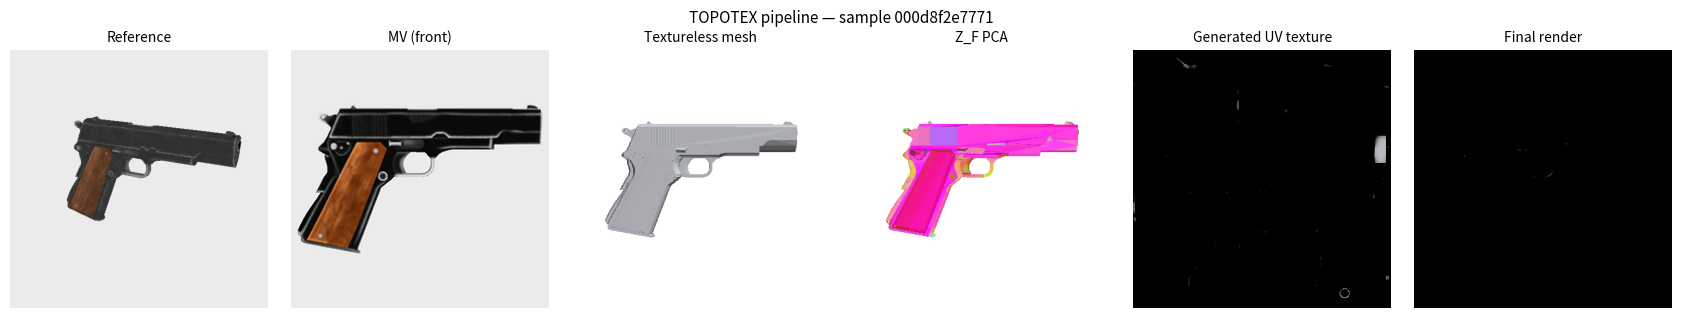

checkpoint: baseline | step 123875 | sample: 000d8f2e77714be8a75c5b9ad0b965e0


In [13]:
fig, axes = plt.subplots(1, 6, figsize=(17, 3.2))
panels = [
    (ref_img, "Reference"),
    (mv_u8[0].permute(1, 2, 0).cpu().numpy(), "MV (front)"),
    (white_front, "Textureless mesh"),
    (pca_render_front, "Z_F PCA"),
    (gens["uv_001"], "Generated UV texture"),
    (rebakes["uv_001"], "Final render"),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis("off")
plt.suptitle("TOPOTEX pipeline — sample " + sid[:12], fontsize=11)
plt.tight_layout(); plt.show()
print("checkpoint:", RUN.name, "| step", ck.get("global_step"),
      "| sample:", sid)